In [1]:
# import statements & checking for cuda
import torch
torch.set_float32_matmul_precision('high')
from ddpm.trainer import LitDDPM
from ddpm.unet import Unet
from helpers import first_radio_galaxy_transform_val, proj_hermitian
from torch.utils.data import DataLoader
from dataset.radio_galaxy_dataset.firstgalaxydata import FIRSTGalaxyData

import numpy as np
from ddrm.svd_replacement import Fourier2D_mask, Fourier2D_weight
from pathlib import Path
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import pandas as pd
from matplotlib.colors import LogNorm

device = torch.device('cuda')

print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    idx = torch.cuda.current_device()
    print("Current device:", idx)
    print("Name:", torch.cuda.get_device_name(idx))
    x = torch.randn(1, device=f"cuda:{idx}")
    print("Tensor device:", x.device)

import os

CUDA available: True
Current device: 0
Name: NVIDIA GeForce RTX 4080 SUPER
Tensor device: cuda:0


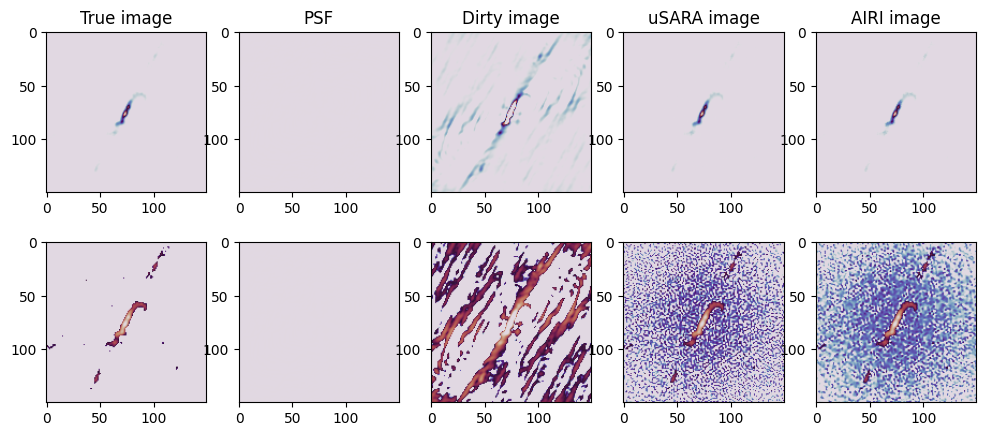

In [ ]:
# input data
true_image = np.load("./data_compare/true_image_2.npy")

from astropy.io import fits
uSARA_image = fits.getdata("./data_compare/uSARA_heuRegScale_1.0_model_image.fits").astype(float)
AIRI_image  = fits.getdata("./data_compare/AIRI_heuScale_1.0_model_image.fits").astype(float)
nufft_dirty = fits.getdata("./data_compare/dirty.fits").astype(float)
nufft_psf   = fits.getdata("./data_compare/psf.fits").astype(float)

#rescale the input image to go from 0 to 1
shift = np.min(true_image)
scale = np.max(true_image)
true_image = (true_image-shift)/(scale-shift)


lognorm = colors.SymLogNorm(linthresh=0.001,vmin=0,vmax=1)
linnorm = colors.Normalize(vmin=0,vmax=1)

fig, ax = plt.subplots(2,5, figsize=(12,5))
ax = ax.flatten()
ax[0].imshow(true_image,norm = linnorm, cmap = "twilight")
ax[0].set_title("True image")
ax[1].imshow(nufft_psf,norm = linnorm,cmap = "twilight")
ax[1].set_title("PSF")
ax[2].imshow(nufft_dirty,norm = linnorm,cmap = "twilight")
ax[2].set_title("Dirty image")
ax[3].imshow(uSARA_image,norm = linnorm,cmap = "twilight")
ax[3].set_title("uSARA image")
ax[4].imshow(AIRI_image,norm = linnorm,cmap = "twilight")
ax[4].set_title("AIRI image")

ax[5].imshow(true_image,norm = lognorm, cmap = "twilight")
ax[6].imshow(nufft_psf,norm = lognorm,cmap = "twilight")
ax[7].imshow(nufft_dirty,norm = lognorm,cmap = "twilight")
ax[8].imshow(uSARA_image,norm = lognorm,cmap = "twilight")
ax[9].imshow(AIRI_image,norm = lognorm,cmap = "twilight")

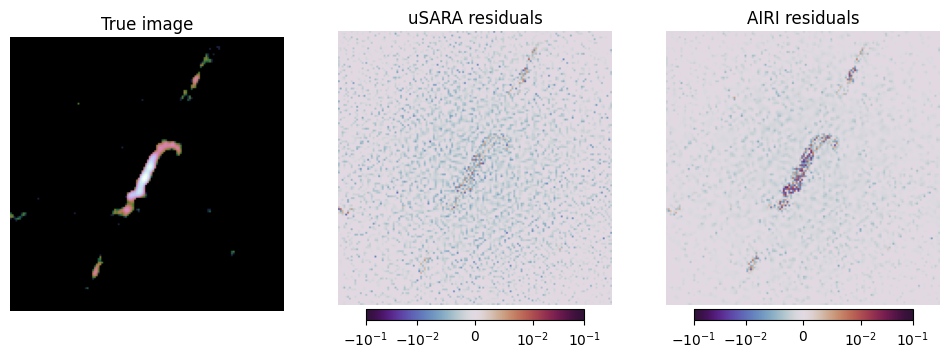

In [3]:
fig, ax = plt.subplots(1,3, figsize=(12,5))
ax = ax.flatten()
for a in ax: a.set_axis_off()
lognorm = colors.SymLogNorm(linthresh=0.01,vmin=0,vmax=1)
resnorm = colors.SymLogNorm(linthresh=0.01,vmin=-.1,vmax=.1)
ax[0].imshow(true_image,norm = lognorm, cmap = "cubehelix")
ax[0].set_title("True image")
cm = ax[1].imshow(true_image-uSARA_image,norm = resnorm,cmap = "twilight_shifted")
ax[1].set_title("uSARA residuals")
fig.colorbar(cm, ax=ax[1], shrink=0.8, pad = 0.01, orientation = 'horizontal')
cm = ax[2].imshow(true_image-AIRI_image,norm = resnorm,cmap = "twilight_shifted")
ax[2].set_title("AIRI residuals")
fig.colorbar(cm, ax=ax[2], shrink=0.8, pad = 0.01, orientation = 'horizontal')


In [4]:
# the simulated observation
from scipy.io import loadmat

meas = loadmat('./data_compare/gal2_sim_data_150x150.mat')
for k, v in meas.items():
    if not k.startswith('__'):
        if max(v.shape) == 1:
            if type(v.item()) == str:
                print(f"{k}: {v.item()}")
            else:
                print(f"{k}: {v.item():.4e}")
        else:
            print(f"{k}: {v.shape}, {type(v)}")

y: (299325, 1), <class 'numpy.ndarray'>
nW: (299325, 1), <class 'numpy.ndarray'>
u: (299325, 1), <class 'numpy.ndarray'>
v: (299325, 1), <class 'numpy.ndarray'>
w: (299325, 1), <class 'numpy.ndarray'>
frequency: 1.0000e+09


In [5]:
normalize = lambda x : (x - x.min()) /  (x.max() - x.min())

(598650,)


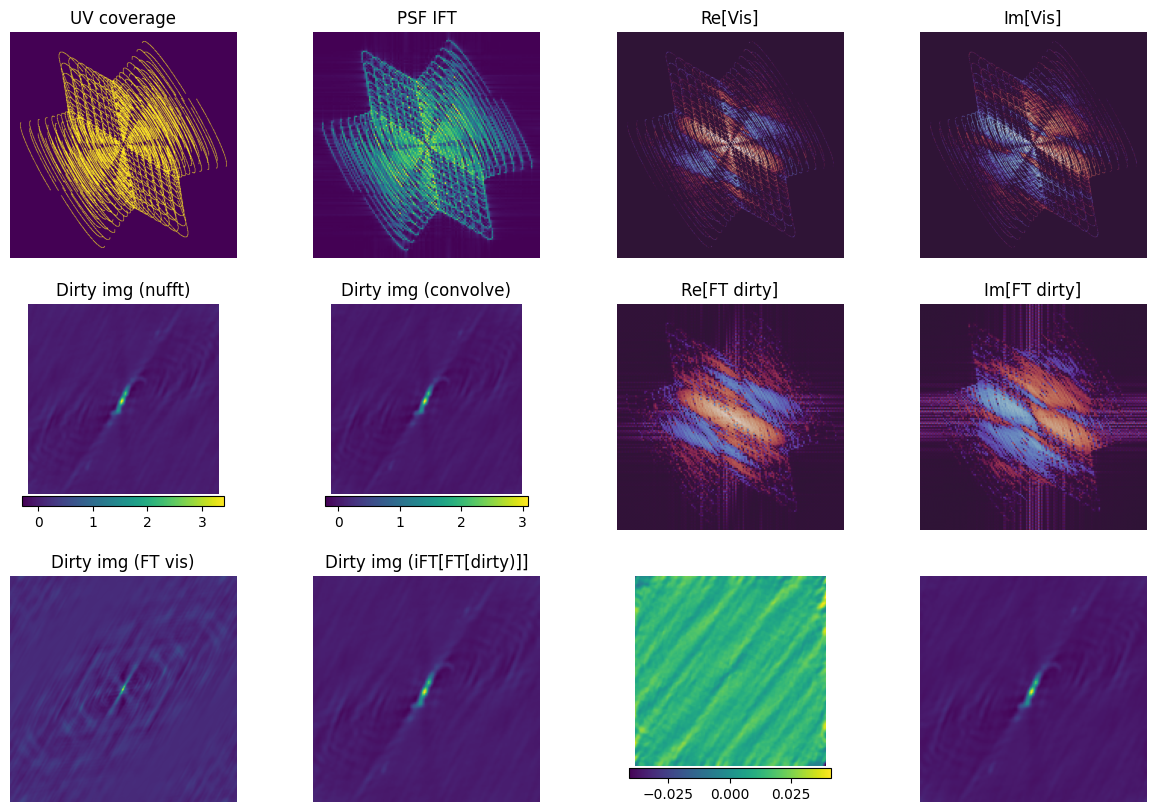

In [6]:
fig, axs = plt.subplots(3,4,figsize=(15,10))
axs = axs.flatten()

u_coords = meas['u'].ravel()
v_coords = meas['v'].ravel()
u_coords = np.hstack([u_coords,-1*u_coords])
v_coords = np.hstack([v_coords,-1*v_coords])
y_img = meas['y'].ravel()
y_img = np.hstack([np.conj(y_img),y_img])/2
print(y_img.shape)

hist_range = [[np.min(u_coords)*1.1, np.max(u_coords)*1.1], [np.min(v_coords)*1.1, np.max(v_coords)*1.1]]
uv_hist, x_edges, y_edges = np.histogram2d(u_coords,v_coords , range = hist_range, bins=512)
gridded_vis_re, _, _ = np.histogram2d(u_coords,v_coords, weights=y_img.real, range = hist_range, bins=512)
gridded_vis_im, _, _ = np.histogram2d(u_coords,v_coords, weights=y_img.imag, range = hist_range, bins=512)
gridded_vis = np.rot90(gridded_vis_re + 1j*gridded_vis_im,k=3)
gridded_vis[uv_hist>0] = gridded_vis[uv_hist>0]/uv_hist[uv_hist>0]
mask = uv_hist > 0
mask = np.rot90(mask,k=3)
mask =torch.from_numpy(mask.copy())

def ft(img):
    return np.fft.ifftshift(np.fft.fft2(np.fft.fftshift(img)))

def ift(vis):
    return (np.fft.fftshift(np.fft.ifft2(np.fft.fftshift(vis)))).real
for a in axs: a.set_axis_off()

axs[0].imshow(mask)
axs[0].set_title("UV coverage")
sampling_weights = np.abs(ft(nufft_psf))
#sampling_weights = np.abs(ft(nufft_dirty))

sampling_weights = sampling_weights/np.mean(sampling_weights)
axs[1].imshow(sampling_weights)
axs[1].set_title("PSF IFT")
axs[2].imshow(gridded_vis.real, norm = colors.SymLogNorm(linthresh=1,vmin=-1000,vmax=1000),cmap = "twilight")
axs[2].set_title("Re[Vis]")
axs[3].imshow(gridded_vis.imag, norm = colors.SymLogNorm(linthresh=1,vmin=-1000,vmax=1000),cmap = "twilight")
axs[3].set_title("Im[Vis]")
cm4 = axs[4].imshow(nufft_dirty)
axs[4].set_title("Dirty img (nufft)")
img_tmp = ift(ft(true_image)*sampling_weights)
cm5 = axs[5].imshow(ift(ft(true_image)*sampling_weights))
axs[5].set_title("Dirty img (convolve)")

fig.colorbar(cm4, ax=axs[4], shrink=0.8, pad = 0.01, orientation = 'horizontal')
fig.colorbar(cm5, ax=axs[5], shrink=0.8, pad = 0.01, orientation = 'horizontal')

vis_from_dirty = ft(nufft_dirty)
axs[6].imshow(vis_from_dirty.real, norm = colors.SymLogNorm(linthresh=1,vmin=-1000,vmax=1000),cmap = "twilight")
axs[6].set_title("Re[FT dirty]")
axs[7].imshow(vis_from_dirty.imag, norm = colors.SymLogNorm(linthresh=1,vmin=-1000,vmax=1000),cmap = "twilight")
axs[7].set_title("Im[FT dirty]")

axs[8].imshow(ift(gridded_vis))
axs[8].set_title("Dirty img (FT vis)")
axs[9].imshow(ift(vis_from_dirty))
axs[9].set_title("Dirty img (iFT[FT[dirty)]]")
cm = axs[10].imshow(normalize(nufft_dirty) - normalize(ift(ft(true_image)*sampling_weights)),norm=colors.CenteredNorm())
fig.colorbar(cm, ax=axs[10], shrink=0.8, pad = 0.01, orientation = 'horizontal')
axs[11].imshow(normalize(img_tmp))

In [7]:
# defining the model

# the image size we use will be 150x150, as set by the pre-trained DDPM
image_size = 150

# define and load the pre-trained DDPM
net = Unet(1, 32, 4, 2, 256).to('cuda')
model = LitDDPM.load_from_checkpoint('checkpoints_real_valued/last-v5.ckpt', unet=net)

Channel per encoder Depth
[32, 64, 128, 256, 512]


In [8]:
# define the sampling operator used by DDRM

# sampling operator H
#mask = torch.from_numpy(np.load('uv_coverages/VLA_mask_150_100steps_uniform.npy'))
#weights = torch.from_numpy(np.load('uv_coverages/VLA_mask_150_100steps_natural.npy'))
#h1 = Fourier2D_mask(channels=1, img_dim=image_size, S=mask, device=device)
weights = torch.from_numpy(sampling_weights)
h1 = Fourier2D_weight(channels=1, img_dim=image_size, S=weights, device=device)

# number of DDRM sampling steps
# increase this number to improve the image reconstruction
num_steps = 1000

# for a single input image, we will denoise batch_size times
# increase this number to get more samples
batch_size = 1

# sigma is the amount of noise added to visibility space
sigma_0 = 0.01#0.1494

# the eta hyperparamt 
eta_A, eta_B, eta_C = 0.85, 1.0, 0.85

torch.Size([1, 22500])
tensor(43406)


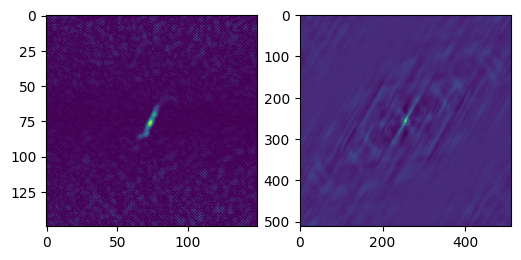

In [9]:
# format the true image x_0
x = torch.from_numpy(true_image * 2.0 - 1.0).float().reshape(1,image_size, image_size)
x_gpu = x.to(device)
x_0 = x_gpu.unsqueeze(0).repeat(batch_size, 1, 1, 1)

# change this to use dirty image??
y1_0 = h1.H(x_0)
y1_0 = y1_0 + sigma_0 * proj_hermitian(torch.randn_like(y1_0) * np.sqrt(2))

x_dirty = h1.H_pinv(y1_0).reshape(batch_size,image_size,image_size).cpu()
x_dirty_display = ((x_dirty + 1) / 2).clamp(0, 1)

print(y1_0.shape)
print(torch.sum(mask))

x_dirty2 = (np.fft.fftshift(np.fft.ifft2(np.fft.fftshift(gridded_vis)))).real

fig, ax = plt.subplots(1,2, figsize=(6, 3))
ax = ax.flatten()
ax[0].imshow(x_dirty_display[0,...])
ax[1].imshow(x_dirty2)

In [10]:

# do the DDRM sampling
with model.ema.average_parameters():
    model.model.eval()
    x_hat, _ = model.model.sample_ddrm_y0(
        image_size, num_steps, y1_0, x_0.shape[0], h1, sigma_0, eta_A, eta_B, eta_C
    )

# rescale the image estimate x_hat
x_hat = ((x_hat[-1] + 1) / 2).clamp(0, 1)      


AUTOTUNE mm(25600x32, 32x64)
strides: [32, 1], [1, 32]
dtypes: torch.float32, torch.float32
  triton_mm_26 0.0123 ms 100.0% ACC_TYPE='tl.float32', ALLOW_TF32=True, BLOCK_K=32, BLOCK_M=64, BLOCK_N=64, EVEN_K=True, GROUP_M=8, USE_FAST_ACCUM=False, num_stages=2, num_warps=4
  triton_mm_31 0.0123 ms 100.0% ACC_TYPE='tl.float32', ALLOW_TF32=True, BLOCK_K=32, BLOCK_M=64, BLOCK_N=64, EVEN_K=True, GROUP_M=8, USE_FAST_ACCUM=False, num_stages=4, num_warps=4
  triton_mm_25 0.0133 ms 92.3% ACC_TYPE='tl.float32', ALLOW_TF32=True, BLOCK_K=16, BLOCK_M=64, BLOCK_N=64, EVEN_K=True, GROUP_M=8, USE_FAST_ACCUM=False, num_stages=2, num_warps=4
  triton_mm_33 0.0133 ms 92.3% ACC_TYPE='tl.float32', ALLOW_TF32=True, BLOCK_K=32, BLOCK_M=128, BLOCK_N=64, EVEN_K=True, GROUP_M=8, USE_FAST_ACCUM=False, num_stages=4, num_warps=8
  triton_mm_27 0.0154 ms 80.0% ACC_TYPE='tl.float32', ALLOW_TF32=True, BLOCK_K=32, BLOCK_M=64, BLOCK_N=64, EVEN_K=True, GROUP_M=8, USE_FAST_ACCUM=False, num_stages=3, num_warps=8
  triton_m

torch.Size([1, 1, 150, 150])
tensor(0.) tensor(0.9911)


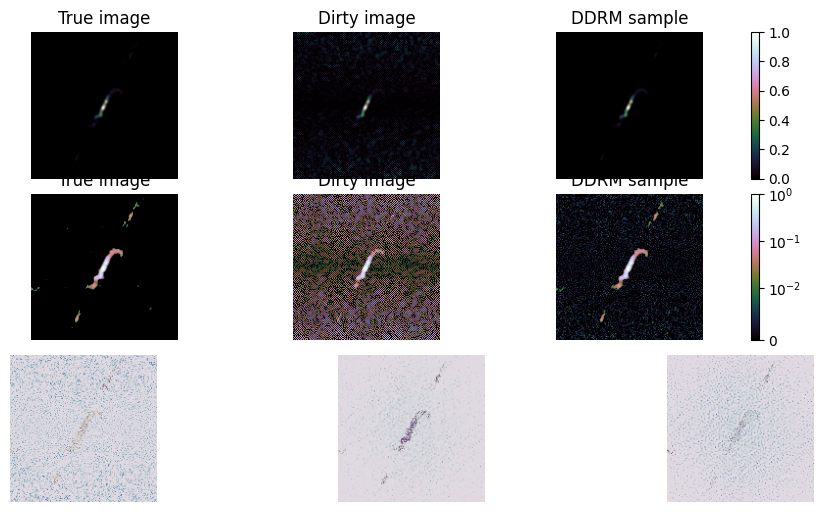

In [11]:
#make plots
fig, ax = plt.subplots(3,3, figsize=(10, 5))
ax = ax.flatten()
for a in ax: a.set_axis_off()
plt.tight_layout()

print(x_hat.shape)
ddrm_image = x_hat[0,...].reshape(image_size,image_size)
print(torch.min(ddrm_image),torch.max(ddrm_image))

cnorm = colors.SymLogNorm(linthresh=0.01,vmin=0,vmax=1)
linnorm = colors.Normalize(vmin=0,vmax=1)
#plt.subplots_adjust(left=0.06, right=0.99, top=0.99, bottom=0.1, wspace=0.0, hspace = 0.1)
pcm = ax[0].imshow(true_image,norm=linnorm,cmap = "cubehelix")
ax[0].set_title("True image")
ax[1].imshow(x_dirty_display[0,...],norm = linnorm,cmap = "cubehelix")
ax[1].set_title("Dirty image")
ax[2].imshow(ddrm_image,norm=linnorm,cmap = "cubehelix")
ax[2].set_title("DDRM sample")
plt.colorbar(pcm, ax=[ax[0],ax[1],ax[2]])

pcm = ax[3].imshow(true_image,norm=cnorm,cmap = "cubehelix")
ax[3].set_title("True image")
ax[4].imshow(x_dirty_display[0,...],norm = cnorm,cmap = "cubehelix")
ax[4].set_title("Dirty image")
ax[5].imshow(ddrm_image,norm=cnorm,cmap = "cubehelix")
ax[5].set_title("DDRM sample")
plt.colorbar(pcm, ax=[ax[3],ax[4],ax[5]])

ax[6].imshow(true_image-ddrm_image.numpy(),norm= colors.SymLogNorm(linthresh=0.01,vmin=-.1,vmax=.1),cmap = "twilight_shifted")
ax[7].imshow(true_image-AIRI_image,norm= colors.SymLogNorm(linthresh=0.01,vmin=-.1,vmax=.1),cmap = "twilight_shifted")
ax[8].imshow(true_image-uSARA_image,norm= colors.SymLogNorm(linthresh=0.01,vmin=-.1,vmax=.1),cmap = "twilight_shifted")

plt.show()